In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/scrnaseq-pipeline/bin/python


In [2]:
import scanpy as sc
import os
import numpy as np 
from scipy.stats import median_abs_deviation

In [3]:
os.chdir('/Volumes/T7 Shield/Project_CV/scrnaseq-pipeline') # move note book to project root 
os.getcwd()

'/Volumes/T7 Shield/Project_CV/scrnaseq-pipeline'

### Peripheral blood mononuclear cells (PBMCs) from a healthy donor (same donor as pbmc6k).

### PBMCs are primary cells with relatively small amounts of RNA (~1pg RNA/cell).


In [4]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [5]:
adata.obs # cells barcode 

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1
...
TTTCGAACTCTCAT-1
TTTCTACTGAGGCA-1
TTTCTACTTCCTCG-1


In [6]:
adata.var

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180


In [7]:
type(adata.X) # sparse matrix do not store zero value -> save memory 


scipy.sparse._csr.csr_matrix

In [8]:
adata.X.toarray() # 0 can be a dropout an mRNA not detected 
                  # rows = cells    col = genes 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2700, 32738), dtype=float32)

In [9]:
adata.shape

(2700, 32738)

In [10]:
adata.X.nnz # number of non 0 value 

2286884

In [11]:
value = 1 - adata.X.nnz/(2700 * 32738)
f"{value:.1%}" # fraction of zero value 

'97.4%'

## QC 

### mitochondrial genes (in human start with MT- )
### human mitochondrial genomes has 37 genes : 13 protein-coding,  22 tRNAs and 2 rRNAs.

In [12]:
adata.var_names

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'KIR3DL2-1', 'AL590523.1', 'CT476828.1', 'PNRC2-1', 'SRSF10-1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='str', name='index', length=32738)

In [13]:
adata.var['MT-'] = adata.var_names.str.startswith('MT-') 
print("number of mitochondrial genes: " ,sum(adata.var['MT-']))

number of mitochondrial genes:  13


In [14]:
print("mitochondrial genes:" , adata.var_names[adata.var['MT-']])

mitochondrial genes: Index(['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3',
       'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='str', name='index')


In [15]:
 sc.pp.calculate_qc_metrics(adata, qc_vars=["MT-"], inplace= True )

In [16]:
adata.obs


,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_MT-,log1p_total_counts_MT-,pct_counts_MT-
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242
...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,7.052721,3461.0,8.149602,39.237215,52.528171,65.761341,81.074834,73.0,4.304065,2.109217
TTTCTACTGAGGCA-1,1227,7.113142,3447.0,8.145550,37.278793,51.900203,63.881636,78.909196,32.0,3.496508,0.928343
TTTCTACTTCCTCG-1,622,6.434547,1684.0,7.429521,45.783848,61.638955,74.940618,92.755344,37.0,3.637586,2.197150


In [17]:
adata.obs.describe()[["n_genes_by_counts", "total_counts","pct_counts_MT-"]]

,n_genes_by_counts,total_counts,pct_counts_MT-
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.262085,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


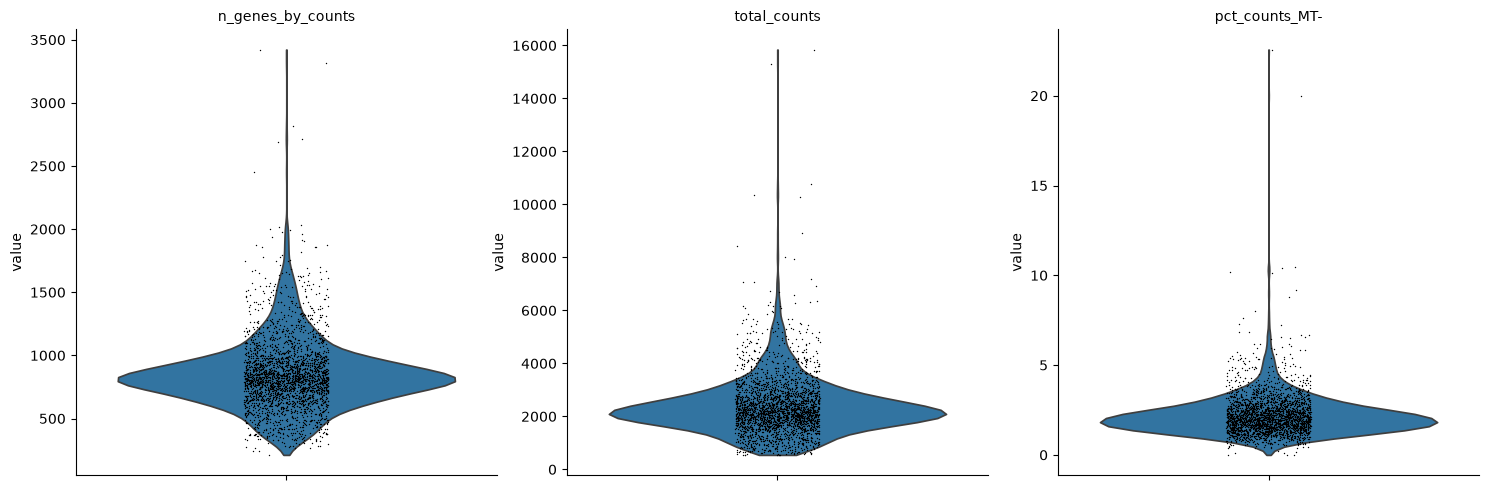

In [18]:
sc.pl.violin(adata, keys = ["n_genes_by_counts", "total_counts","pct_counts_MT-"], multi_panel=True )

#### MAD-based filtering

In [19]:
MAD = median_abs_deviation(adata.obs['log1p_n_genes_by_counts'])
print(MAD)
median = np.median(adata.obs['log1p_n_genes_by_counts'])
print(median)
thresh_pos   = median + 5*MAD
thresh_under = median - 5*MAD
adata.obs['outlier_n_genes'] = (adata.obs['log1p_n_genes_by_counts'] > thresh_pos) | (adata.obs['log1p_n_genes_by_counts'] < thresh_under)

0.16007094785913534
6.706862336602747


In [20]:
print("nb of oulier gene:", sum(adata.obs['outlier_n_genes']))
print("nb of oulier gene above:", sum(adata.obs['log1p_n_genes_by_counts'] > thresh_pos))
print("nb of oulier gene under:", sum(adata.obs['log1p_n_genes_by_counts'] < thresh_under))
print("thresh used:" , "above", np.expm1(thresh_pos), "n_genes_by_counts and under " , np.expm1(thresh_under),"n_genes_by_counts")

nb of oulier gene: 79
nb of oulier gene above: 20
nb of oulier gene under: 59
thresh used: above 1820.1383942857062 n_genes_by_counts and under  366.4207309557305 n_genes_by_counts


In [21]:
def is_outlier(adata,col_name , nMAD,upper_only=False):
    MAD = median_abs_deviation(adata.obs[col_name])
    median = np.median(adata.obs[col_name])
    thresh_pos   = median + nMAD * MAD
    
    if upper_only == True:
        mask = adata.obs[col_name] > thresh_pos
        print("nb of oulier",col_name,"above:", sum(adata.obs[col_name] > thresh_pos))
        print("thresh used:" , "above", thresh_pos)
        
    else:
        thresh_under = median - nMAD * MAD
        mask = (adata.obs[col_name] > thresh_pos) | (adata.obs[col_name] < thresh_under)
        print("nb of oulier",col_name, ":", sum(mask))
        print("nb of oulier",col_name,"above:", sum(adata.obs[col_name] > thresh_pos))
        print("nb of oulier",col_name,"under:", sum(adata.obs[col_name] < thresh_under))
        print("thresh used:" , "above", thresh_pos, " and under " , thresh_under)
    return mask

adata.obs['outlier_n_genes_by_counts'] = is_outlier(adata, "log1p_n_genes_by_counts", 5)
adata.obs['outlier_total_counts'] = is_outlier(adata, "log1p_total_counts", 5)
adata.obs['outlier_pct_counts_MT-'] = is_outlier(adata, "pct_counts_MT-", 3, upper_only= True)
 

nb of oulier log1p_n_genes_by_counts : 79
nb of oulier log1p_n_genes_by_counts above: 20
nb of oulier log1p_n_genes_by_counts under: 59
thresh used: above 7.507217075898423  and under  5.90650759730707
nb of oulier log1p_total_counts : 58
nb of oulier log1p_total_counts above: 13
nb of oulier log1p_total_counts under: 45
thresh used: above 8.826466  and under  6.5641403
nb of oulier pct_counts_MT- above: 202
thresh used: above 3.6501262


In [22]:
adata.obs["qc_fail"] = (adata.obs['outlier_n_genes_by_counts'])|(adata.obs['outlier_total_counts'] )|(adata.obs['outlier_pct_counts_MT-'] )
print("outlier_n_genes_by_counts:",sum(adata.obs["outlier_n_genes_by_counts"]))
print("outlier_total_counts:",sum(adata.obs["outlier_total_counts"]))
print("outlier_pct_counts_MT-:",sum(adata.obs["outlier_pct_counts_MT-"]))
print("qc_fail:",sum(adata.obs["qc_fail"]))
print("% of outlier: ",adata.obs["qc_fail"].mean())

outlier_n_genes_by_counts: 79
outlier_total_counts: 58
outlier_pct_counts_MT-: 202
qc_fail: 266
% of outlier:  0.09851851851851852


In [23]:
adata_clean = adata[~adata.obs["qc_fail"] ].copy()
adata_clean

AnnData object with n_obs × n_vars = 2434 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT-', 'log1p_total_counts_MT-', 'pct_counts_MT-', 'outlier_n_genes', 'outlier_n_genes_by_counts', 'outlier_total_counts', 'outlier_pct_counts_MT-', 'qc_fail'
    var: 'gene_ids', 'MT-', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: None (.X)